# IPL 2022 Capstone Project

#### The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

#### These are some of the important columns that we'll focus on for meaningful insights in this project.

#### column names: Variable Type

- date : string
- venue : string
- stage : string
- team1 : string
- team2 : string
- toss_winner : string
- toss_decision : string
- first_ings_score : integer
- second_ings_score : integer
- match_winner : string
- won_by : string
- margin : integer
- player_of_the_match : string
- top_scorer : string
- highscore : integer
- best_bowling : string
- best_bowling_fgure : string
- gure : string

### Loading the Libraries and Dataset

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings # to handle warnings so no code feels bad
warnings.filterwarnings("ignore")

df = pd.read_csv('IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [7]:
df.shape

(74, 20)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [9]:
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]}")

your rows are 74 and your columns are 20


In [10]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [11]:
df['team1'].value_counts()

team1
Banglore     16
Chennai      12
Delhi        12
Gujarat      10
Hyderabad     7
Kolkata       7
Lucknow       6
Mumbai        3
Punjab        1
Name: count, dtype: int64

##### Now, here comes some basic questions

1. Which team won the most matches?

Text(0.5, 1.0, 'Most matches by team')

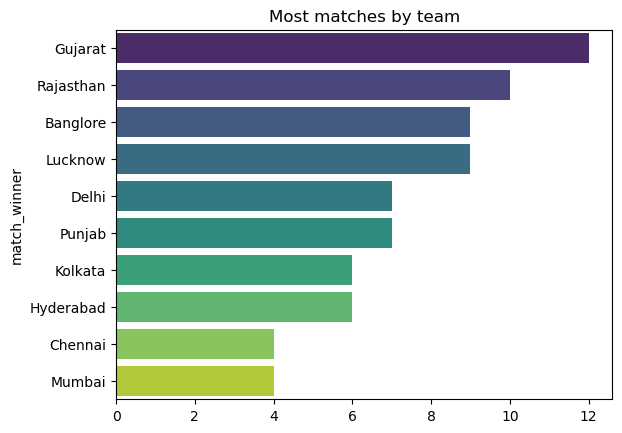

In [17]:
match_wins = df['match_winner'].value_counts()
sns.barplot(y = match_wins.index, x = match_wins.values, palette='viridis')
plt.title("Most matches by team")

2. Toss  decision trends

Text(0.5, 1.0, 'Toss Decision Trends')

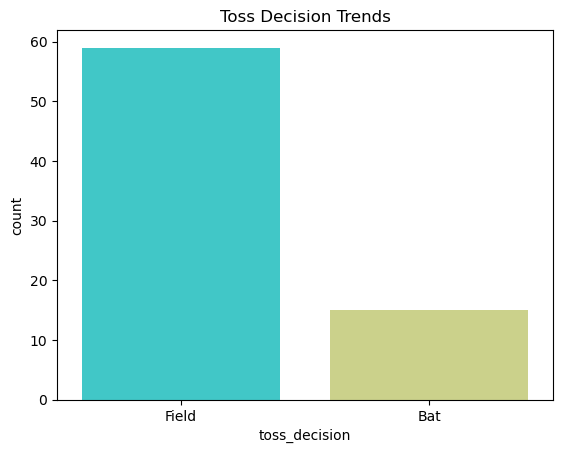

In [20]:
sns.countplot(x = df['toss_decision'], palette='rainbow')
plt.title("Toss Decision Trends")

3. Toss winner vs Match Winner

In [28]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count * 100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

4. How do teams win? (RUns vs Wickets)

Text(0.5, 1.0, 'Won By')

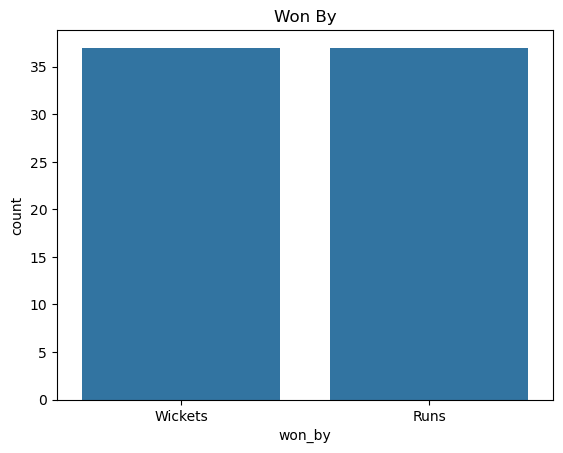

In [30]:
sns.countplot(x = df['won_by'])
plt.title("Won By")

### Key Player Performances

1. Most "Player of the Match" Awards

In [40]:
count = df['player_of_the_match'].value_counts().head(20)
count

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Quinton de Kock      2
David Miller         2
Umran Malik          2
K L Rahul            2
Rahul Tripathi       2
Hardik Pandya        2
Jasprit Bumrah       2
Shubman Gill         2
Yuzvendra Chahal     2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Virat Kohli          1
Rinku Singh          1
Kagiso Rabada        1
Harshal Patel        1
David Warner         1
Name: count, dtype: int64

Text(0.5, 1.0, 'Top 20 Players who won "Man of the Match" Award')

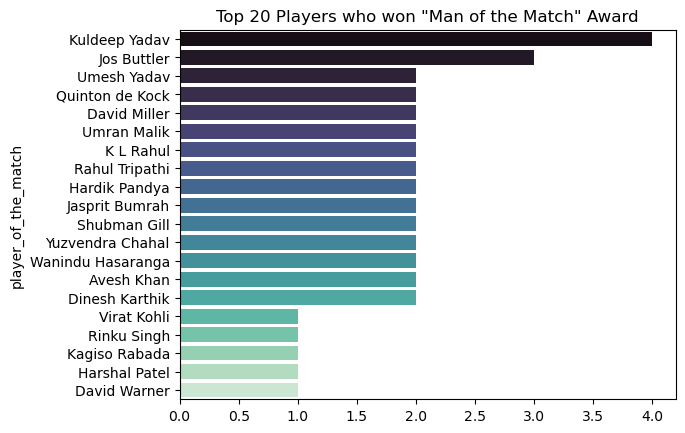

In [44]:
sns.barplot(x = count.values, y = count.index, palette='mako')
plt.title('Top 20 Players who won "Man of the Match" Award')

2. Top Scorer

In [46]:
top_scorer = df['top_scorer'].value_counts().head(20)
top_scorer

top_scorer
Jos Buttler         7
Quinton de Kock     5
Liam Livingstone    4
Shubman Gill        4
KL Rahul            4
W. Saha             3
Faf du Plessis      3
Ishan Kishan        3
David Warner        3
Rahul Tripathi      2
Devon Conway        2
Abhishek Sharma     2
MS Dhoni            2
Hardik Pandya       2
Andre Russell       2
Mitchell Marsh      2
Virat Kohli         2
Deepak Hooda        2
Shikhar Dhawan      2
Ruturaj Gaikwad     1
Name: count, dtype: int64

In [51]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(5)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
KL Rahul           351
Shubman Gill       288
Faf du Plessis     257
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

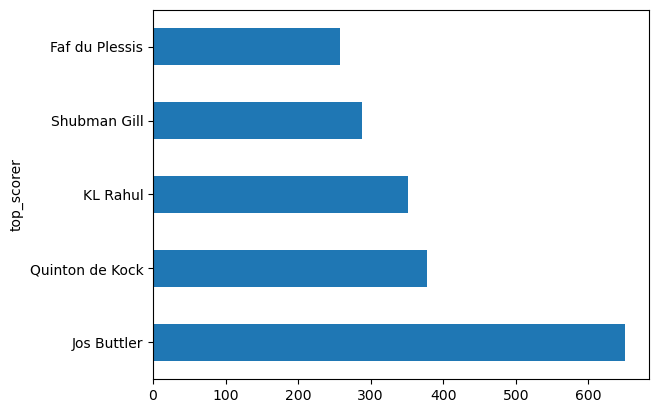

In [53]:
high.plot(kind='barh')

#### 10 Best Bowling Figures

In [58]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x : x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)

In [59]:
top_bowlers

best_bowling
Yuzvendra Chahal     17
Kuldeep Yadav        11
Rashid Khan          11
Jasprit Bumrah       11
Avesh Khan           10
Josh Hazlewood       10
Kagiso Rabada        10
Wanindu Hasaranga     9
Umran Malik           9
T Natarajan           8
Name: highest_wickets, dtype: int64

<Axes: ylabel='best_bowling'>

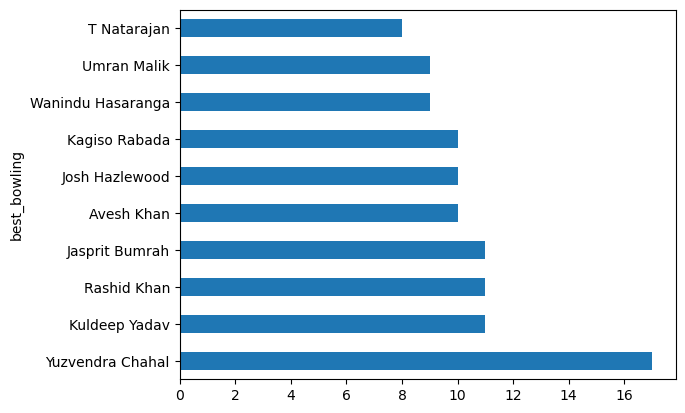

In [61]:
top_bowlers.plot(kind='barh')

### Venue Analysis

1. Most Matches Played by Venue

In [62]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

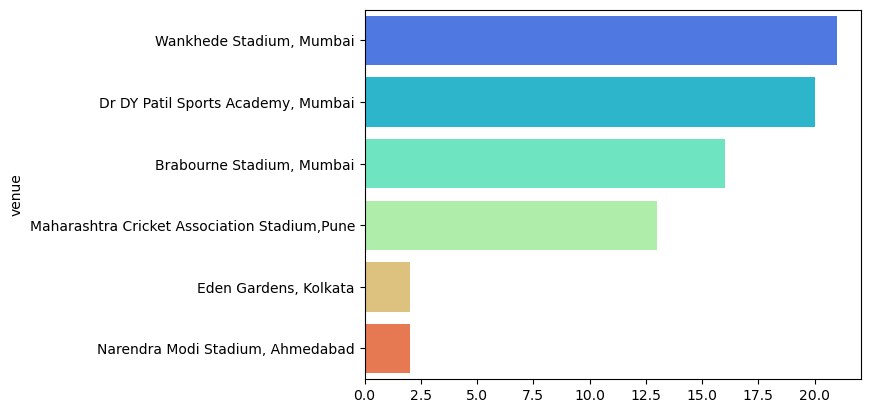

In [64]:
sns.barplot(x = venue_count.values, y = venue_count.index, palette='rainbow')

### Custom Questions and Insights

1. Who won the highest margin by runs?

In [70]:
df[df['won_by'] == 'Runs'].sort_values(by = 'margin', ascending=False).head(1)[['match_winner', 'margin']]

,match_winner,margin
54,Chennai,91


2. Which player had the highest individual score?

In [73]:
df[df['highscore'] == df['highscore'].max()][['top_scorer', 'highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


3. Which bowler had the best bowling figures?

In [76]:
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling', 'best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
